In [1]:
import sys

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch

from configuration import VAE_CKPT_PATH, OUTPUT_DIR, KL_WEIGHT, KL_ANNEAL_EPOCHS

FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Loading checkpoint from:', VAE_CKPT_PATH)

Loading checkpoint from: ../musdb18/output/vae_checkpoint.pt


In [2]:
# ── Load history ───────────────────────────────────────────────────────────────
ckpt    = torch.load(VAE_CKPT_PATH, map_location='cpu')
history = ckpt['history']

epochs      = [h['epoch']       for h in history]
train_recon = [h['train_recon'] for h in history]
val_recon   = [h['val_recon']   for h in history]
train_kl    = [h['train_kl']    for h in history]
val_kl      = [h['val_kl']      for h in history]
kl_weights  = [h.get('kl_weight', KL_WEIGHT) for h in history]

print(f'Loaded {len(history)} epochs')
print(f'Final train recon : {train_recon[-1]:.4f}')
print(f'Final val   recon : {val_recon[-1]:.4f}')
print(f'Final train KL    : {train_kl[-1]:.4f}')
print(f'Final val   KL    : {val_kl[-1]:.4f}')

Loaded 30 epochs
Final train recon : 0.0414
Final val   recon : 0.0421
Final train KL    : 1.9025
Final val   KL    : 1.8586


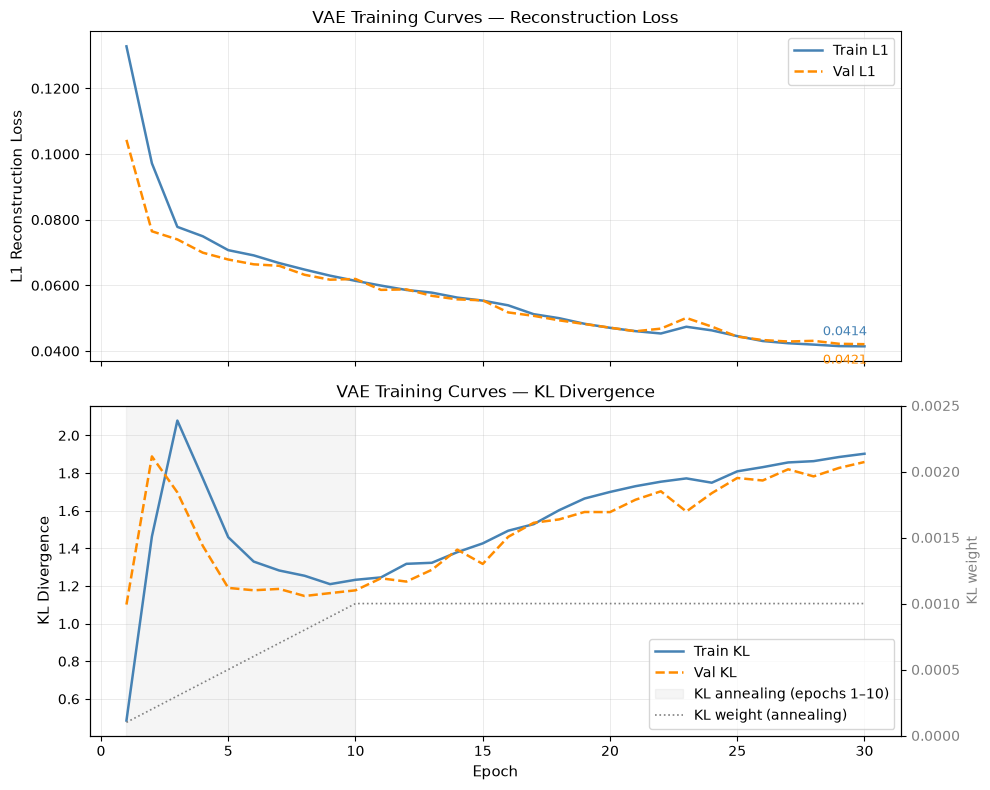

Saved: ../musdb18/output/figures/vae_training_curves.png


In [3]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


ax1.plot(epochs, train_recon, label='Train L1', color='steelblue',  linewidth=1.8)
ax1.plot(epochs, val_recon,   label='Val L1',   color='darkorange', linewidth=1.8,
         linestyle='--')
ax1.set_ylabel('L1 Reconstruction Loss', fontsize=11)
ax1.set_title('VAE Training Curves — Reconstruction Loss', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.35)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))


ax1.annotate(f'{train_recon[-1]:.4f}', xy=(epochs[-1], train_recon[-1]),
             xytext=(-30, 8), textcoords='offset points', fontsize=9,
             color='steelblue')
ax1.annotate(f'{val_recon[-1]:.4f}', xy=(epochs[-1], val_recon[-1]),
             xytext=(-30, -14), textcoords='offset points', fontsize=9,
             color='darkorange')

ax2.plot(epochs, train_kl, label='Train KL', color='steelblue',  linewidth=1.8)
ax2.plot(epochs, val_kl,   label='Val KL',   color='darkorange', linewidth=1.8,
         linestyle='--')
ax2.set_ylabel('KL Divergence', fontsize=11)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_title('VAE Training Curves — KL Divergence', fontsize=12)
ax2.grid(True, alpha=0.35)

ax2b = ax2.twinx()
ax2b.plot(epochs, kl_weights, color='grey', linewidth=1.2, linestyle=':',
          label='KL weight (annealing)')
ax2b.set_ylabel('KL weight', fontsize=10, color='grey')
ax2b.tick_params(axis='y', labelcolor='grey')
ax2b.set_ylim(0, KL_WEIGHT * 2.5)

anneal_end = min(KL_ANNEAL_EPOCHS, max(epochs))
ax2.axvspan(1, anneal_end, alpha=0.08, color='grey', label=f'KL annealing (epochs 1–{anneal_end})')


lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=10)

plt.tight_layout()
out_path = FIGURES_DIR / 'vae_training_curves.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)